In [81]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [66]:
df = pd.read_csv("processed.cleveland.csv")

In [ ]:
df.replace("?", np.nan, inplace=True)
df['thao'] = df['thao'].astype(float)
df['num'] = df['num'].astype(float)

df['thao'].fillna(df['thao'].mean(),inplace=True)
df['num'].fillna(df['num'].mean(),inplace=True)

df['ca'] = df['ca'].astype(float)



/var/folders/6x/cw89xb1x1f7c87g5_m1hrq040000gn/T/ipykernel_48867/3532122204.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['thao'].fillna(df['thao'].mean(),inplace=True)
/var/folders/6x/cw89xb1x1f7c87g5_m1hrq040000gn/T/ipykernel_48867/3532122204.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Se

In [68]:
df['num'].unique()

array([0., 2., 1., 3., 4.])

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thao      301 non-null    float64
 13  num       303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [70]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thao        2
num         0
dtype: int64

num         1.000000
ca          0.518909
thao        0.509923
oldpeak     0.504092
cp          0.407075
exang       0.397057
slope       0.377957
sex         0.224469
age         0.222853
restecg     0.183696
trestbps    0.157754
chol        0.070909
fbs         0.059186
thalach    -0.415040
Name: num, dtype: float64

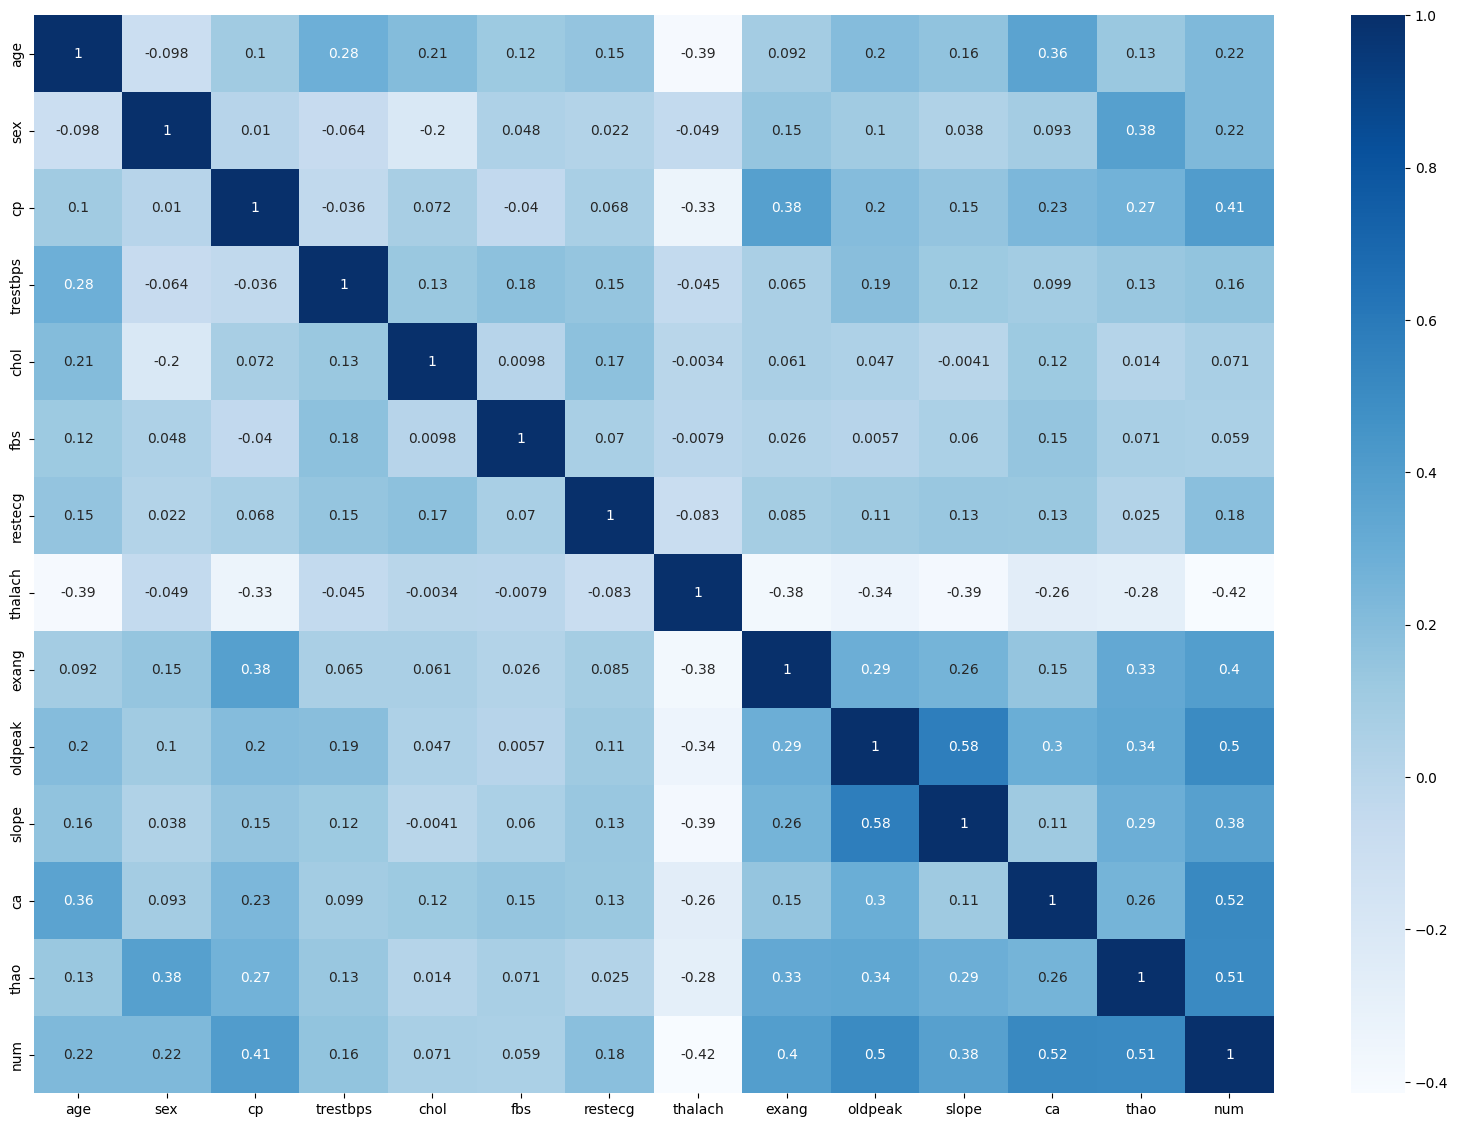

In [83]:
plt.figure(figsize=(20,14))
sns.heatmap(df.corr(),annot=True,cmap='Blues')

corr = df.corr(numeric_only=True)
corr['num'].sort_values(ascending=False)

# df.info()

# Normal Linear Regression

[[62.  0.  4. ...  3.  2.  3.]
 [59.  1.  1. ...  1.  2.  3.]
 [43.  1.  4. ...  2.  0.  3.]
 ...
 [51.  1.  3. ...  1.  1.  7.]
 [62.  1.  2. ...  1.  0.  3.]
 [67.  0.  3. ...  2.  0.  7.]]
MSE: 0.985928899614799
RMSE: 0.9929395246513248


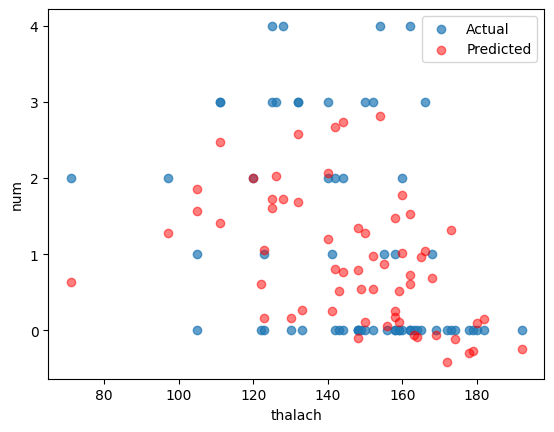

In [72]:
from sklearn.impute import SimpleImputer

features = df.drop('num',axis=1).values
target = df['num'].values

# Impute missing values in features (fill NaNs with column mean)
imputer = SimpleImputer(strategy='mean')
features = imputer.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=3
)

print(X_train)
reg = LinearRegression()
feature_thalach = features[:,7]
feature_thalach = feature_thalach.reshape(-1,1)


reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)


mse = MSE(y_test, y_pred)
print("MSE:", mse)
rmse = mse ** 0.5
print("RMSE:", rmse)


# Plot actual vs predicted for thalach on the test set
X_test_thalach = X_test[:,7]
plt.scatter(X_test_thalach, y_test, alpha=0.7, label='Actual')
plt.scatter(X_test_thalach, y_pred, color='red', alpha=0.5, label='Predicted')
plt.ylabel("num")
plt.xlabel("thalach")
plt.legend()


# Decision Tree Entropy

In [75]:
features = df[['thalach', 'oldpeak', 'cp', 'exang', 'slope', 'age']].values
y = df['num'].to_numpy()

X_train , X_test , y_train , y_test = train_test_split(features,target,test_size=0.3,random_state=1,stratify=y)

dt = DecisionTreeClassifier(criterion='entropy',max_depth=4, min_samples_leaf=1, random_state=1)

# Fit dt to training set
dt.fit(X_train, y_train)

# Predict test-sets labels
y_pred = dt.predict(X_test)

accuracy_score(y_test,y_pred)



0.5384615384615384

# Decision Tree Gini

In [80]:
features = df[['thalach', 'oldpeak', 'cp', 'exang', 'slope', 'age']].values
y = df['num'].to_numpy()

X_train , X_test , y_train , y_test = train_test_split(features,target,test_size=0.3,random_state=1,stratify=y)

dt = DecisionTreeClassifier(criterion='gini',max_depth=4, min_samples_leaf=5, random_state=1)

# Fit dt to training set
dt.fit(X_train, y_train)

# Predict test-sets labels
y_pred = dt.predict(X_test)

accuracy_score(y_test,y_pred)



0.5714285714285714

# Voting Classifier 

In [78]:
SEED = 123
X_train , X_test , y_train , y_test = train_test_split(features,target,test_size=0.3,random_state=1,stratify=y)

lr = LogisticRegression(random_state=SEED)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=SEED)

classifiers = [('logistic Regression', lr ), ("K Nearest Neighbours" , knn) , ("Classification Tree" , dt) ] 

for clf_name , clf in classifiers:
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)

    # Evaluation of score
    # print('{:s} : {:.3f}'.format(clf_name,accuracy_score(X_test,y_test)))
    print(f"{clf_name} : {accuracy_score(y_test, y_pred):.3f}")

vc = VotingClassifier(estimators=classifiers)

vc.fit(X_train,y_train)
y_pred = vc.predict(X_test)

# Evaluating the best score
print(f"Voting Classifier : {accuracy_score(y_test, y_pred):.3f}")


logistic Regression : 0.593
K Nearest Neighbours : 0.516
Classification Tree : 0.418
Voting Classifier : 0.560


/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
 

In [79]:
df['num'].value_counts()

num
0.0    164
1.0     55
2.0     36
3.0     35
4.0     13
Name: count, dtype: int64

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5824175824175825
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.98      0.81        49
         1.0       0.50      0.12      0.19        17
         2.0       0.14      0.09      0.11        11
         3.0       0.22      0.20      0.21        10
         4.0       0.00      0.00      0.00         4

    accuracy                           0.58        91
   macro avg       0.31      0.28      0.27        91
weighted avg       0.51      0.58      0.51        91

